# Drive Finance Data Analysis Assessment

**context:** standalone data analysis (no chatbot / API / LLM).

This notebook explores the Drive Finance CSVs, validates them against ERD Diagram.png, answers the required business questions, and surfaces one original insight.



## 0. Setup

In [17]:
from pathlib import Path
import sys
import sqlite3

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.load_data import load_all, CSV_TO_ERD
from src import run_analysis as ra

sns.set_theme(style='whitegrid', context='notebook')
# Show full tables — no row/column/width truncation in notebook outputs
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.max_seq_item', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

frames = load_all(ROOT)
conn = ra.build_sql_db(frames)
enriched = ra.enrich(frames)
ASOF = ra.ASOF
print('Loaded', {k: v.shape for k, v in frames.items()})
print('Analysis as-of:', ASOF.date())


Loaded {'hierarchy_levels': (6, 3), 'territories': (10, 3), 'employees': (104, 11), 'users': (464, 11), 'employee_customer_assignment': (464, 5), 'finance': (420, 7), 'loan': (420, 13), 'installments': (12282, 10), 'employee_kpi': (10, 7), 'commissions': (420, 5)}
Analysis as-of: 2026-07-30


## Part 1 — Exploratory Data Analysis

### 1.1 ERD and CSV mapping

Canonical model: ERD Diagram.png. CSV names differ slightly from ERD entity names.


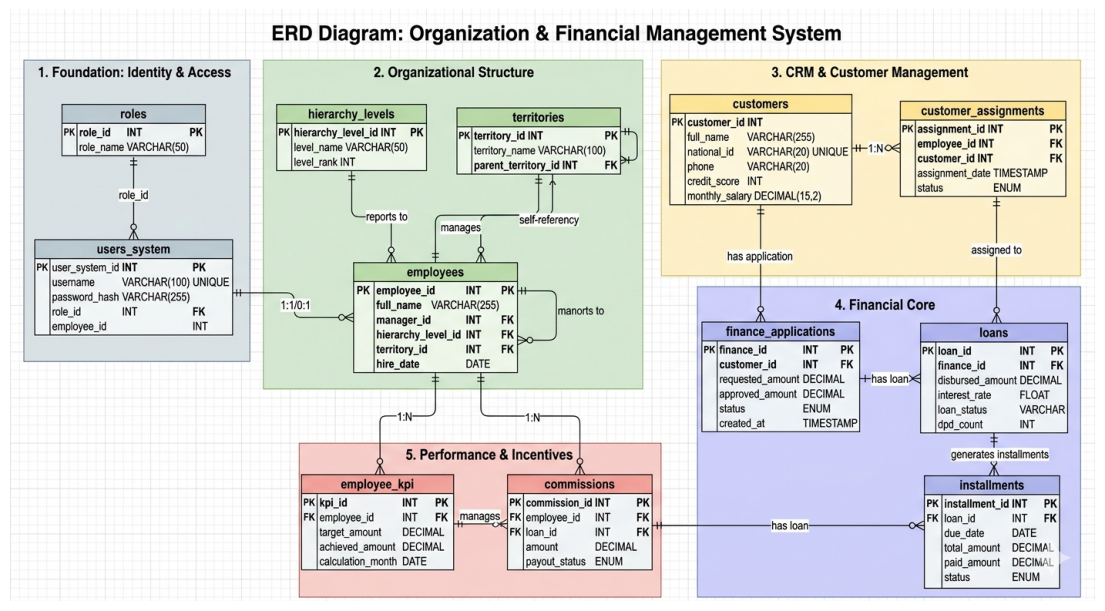

,csv,erd_entity,rows,columns
0,hierarchy_levels,hierarchy_levels,6,3
1,territories,territories,10,3
2,employees,employees,104,11
3,users,customers,464,11
4,employee_customer_assignment,customer_assignments,464,5
5,finance,finance_applications,420,7
6,loan,loans,420,13
7,installments,installments,12282,10
8,employee_kpi,employee_kpi,10,7
9,commissions,commissions,420,5


In [18]:
erd_path = ROOT / 'ERD Diagram.png'
img = mpimg.imread(erd_path)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)
ax.axis('off')
plt.show()

map_df = pd.DataFrame([
    {'csv': k, 'erd_entity': v, 'rows': len(frames[k]), 'columns': frames[k].shape[1]}
    for k, v in CSV_TO_ERD.items()
])
map_df


### 1.2 Shape, keys, and referential integrity

In [19]:
for name, df in frames.items():
    print(f'=== {name} ({CSV_TO_ERD[name]}) {df.shape} ===')
    print(df.dtypes.to_string())
    print()

eda = ra.part1_eda(frames)
print('FK orphan checks:')
display(pd.Series(eda['fk_issues'], name='count').to_frame())
print('\nQuality notes:')
for n in eda['notes']:
    print('-', n)
print('\nNull counts (non-empty only):')
display(eda['nulls'])


=== hierarchy_levels (hierarchy_levels) (6, 3) ===
hierarchy_level_id    int64
level_name              str
level_rank            int64

=== territories (territories) (10, 3) ===
territory_id             int64
territory_name             str
parent_territory_id    float64

=== employees (employees) (104, 11) ===
employee_id                    int64
employee_code                    str
full_name                        str
email                            str
phone                          int64
hire_date             datetime64[us]
manager_id                   float64
hierarchy_level_id             int64
territory_id                   int64
employment_status                str
created_at            datetime64[us]

=== users (customers) (464, 11) ===
user_id                       int64
full_name                       str
phone                         int64
national_id                   int64
city                            str
credit_score                  int64
employer                    

,count
assign_orphan_employee,0
assign_orphan_user,0
loan_orphan_finance,0
installment_orphan_loan,0
commission_orphan_employee,0
commission_orphan_loan,0
finance_without_loan,0
users_without_assignment,0



Quality notes:
- maturity_date is always 30 days after disbursement despite tenure_months ranging 6-60 — treat maturity_date as unreliable; use tenure_months.
- dpd coding: Delayed loans are [-29] (negative values are expected); Active/Closed are 0. Average DPD is a valid portfolio metric.
- Expected nulls: manager_id (CEO), parent_territory_id (Egypt root), payment_date (unpaid/pending).
- ERD tables roles / users_system are not in the CSV extract — out of scope, not a quality defect.

Null counts (non-empty only):


{'territories': {'parent_territory_id': 1},
 'employees': {'manager_id': 1},
 'installments': {'payment_date': 5967}}

### 1.3 Key distributions

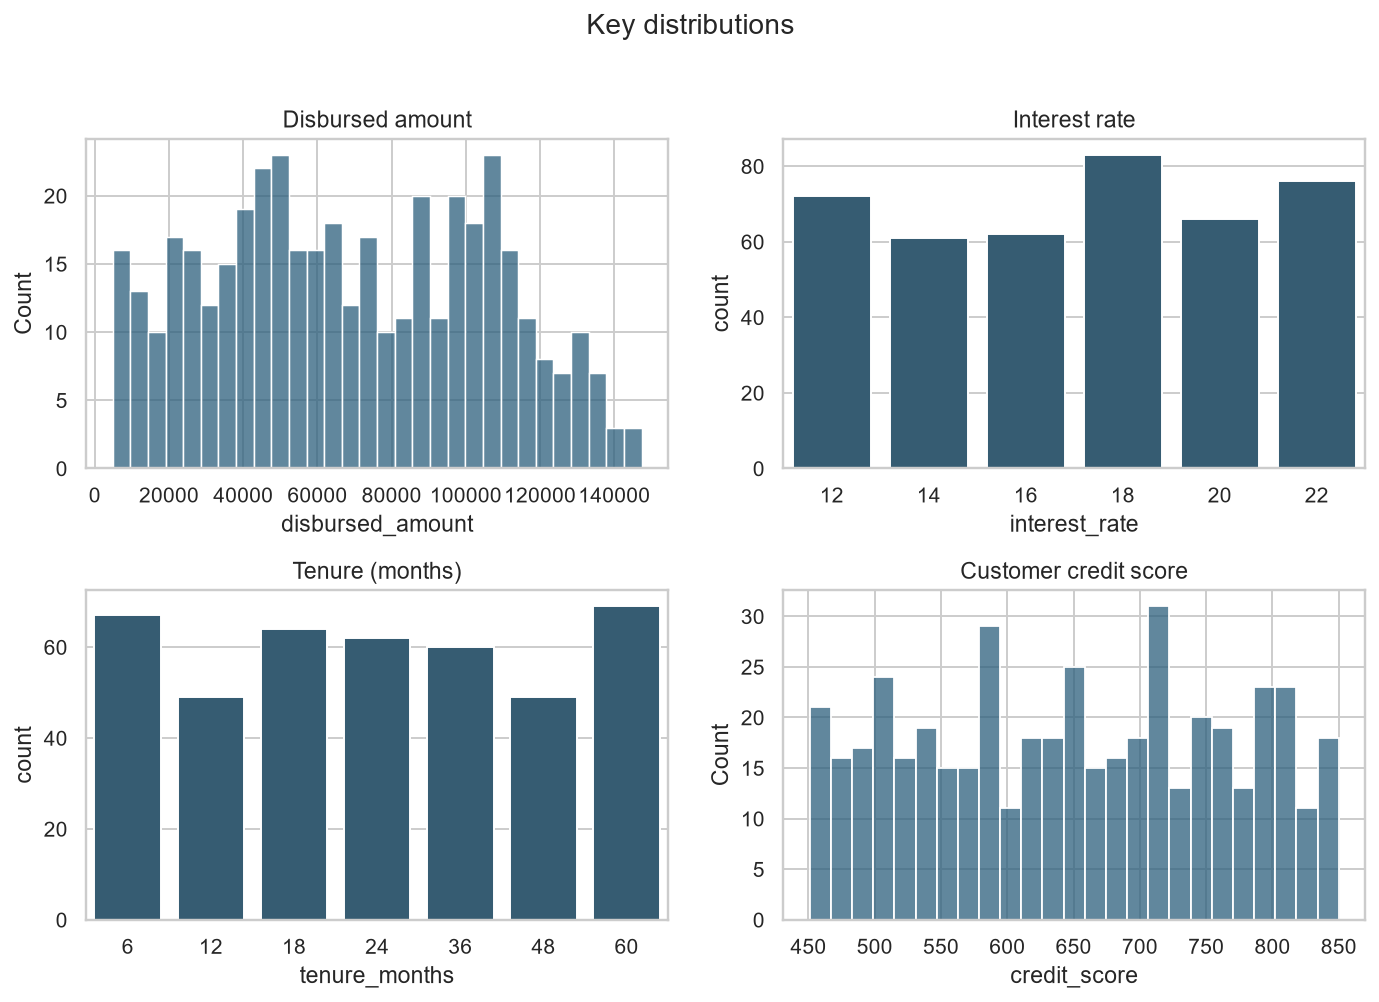

Disbursed amount describe:


count       420.00
mean     68,760.82
std      36,677.58
min       4,809.00
25%      39,519.00
50%      65,343.00
75%     100,358.25
max     147,383.00
Name: disbursed_amount, dtype: float64

Interest rate value counts:


interest_rate
12    72
14    61
16    62
18    83
20    66
22    76
Name: count, dtype: int64

Tenure months:


tenure_months
6     67
12    49
18    64
24    62
36    60
48    49
60    69
Name: count, dtype: int64

Credit score describe:


count   464.00
mean    649.78
std     114.82
min     451.00
25%     553.00
50%     648.00
75%     746.25
max     850.00
Name: credit_score, dtype: float64

Employees per territory:


territory_name
Cairo           23
Giza            21
Alx             16
Direct Sales    15
El Bahira       10
El Delta         9
Upper Egypt      7
Egypt            3
dtype: int64

In [20]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '01_distributions.png')))
loan = frames['loan']
users = frames['users']
print('Disbursed amount describe:')
display(loan['disbursed_amount'].describe())
print('Interest rate value counts:')
display(loan['interest_rate'].value_counts().sort_index())
print('Tenure months:')
display(loan['tenure_months'].value_counts().sort_index())
print('Credit score describe:')
display(users['credit_score'].describe())
print('Employees per territory:')
display(
    frames['employees'].merge(frames['territories'], on='territory_id')
    .groupby('territory_name').size().sort_values(ascending=False)
)


## Part 2 — Business Questions

Each answer: query/code → result → short interpretation.


### Q1. Overall loan portfolio health

,loan_status,n_loans,pct,outstanding,avg_dpd
0,Active,275,65.50,"11,683,885.00",0.00
1,Closed,102,24.30,"3,994,951.00",0.00
2,Delayed,43,10.20,"1,977,329.00",-29.00


Total outstanding: 17,656,165.00


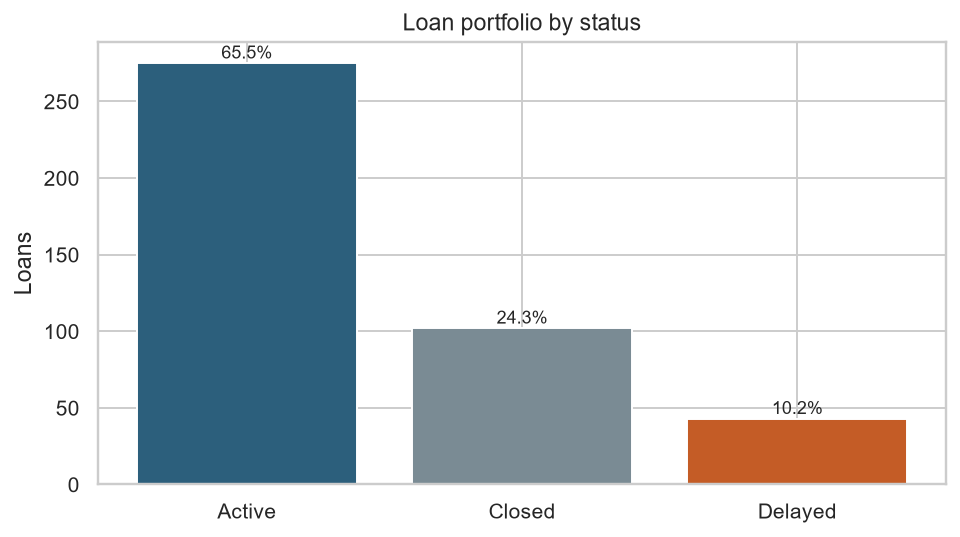

The book is 275 Active / 102 Closed / 43 Delayed loans (10.2% delayed). Total outstanding is 17,656,165. 


In [21]:
q1 = ra.q1_portfolio_health(frames, conn)
display(q1['by_status'])
print(f"Total outstanding: {q1['total_outstanding']:,.2f}")
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '02_portfolio_status.png')))
print(q1['interpretation'])


### Q2. Territories over- and under-performing




,territory_name,n_loans,disbursed,outstanding,delayed_rate,due_installments,overdue,overdue_rate
0,Direct Sales,123,8893592,5280284,0.06,246,32,0.13
1,Egypt,134,8774601,5202006,0.12,268,22,0.08
2,Alx,84,5678709,3665306,0.11,168,14,0.08
3,El Bahira,46,3220781,1998245,0.11,92,4,0.04
4,Upper Egypt,33,2311860,1510324,0.18,66,7,0.11


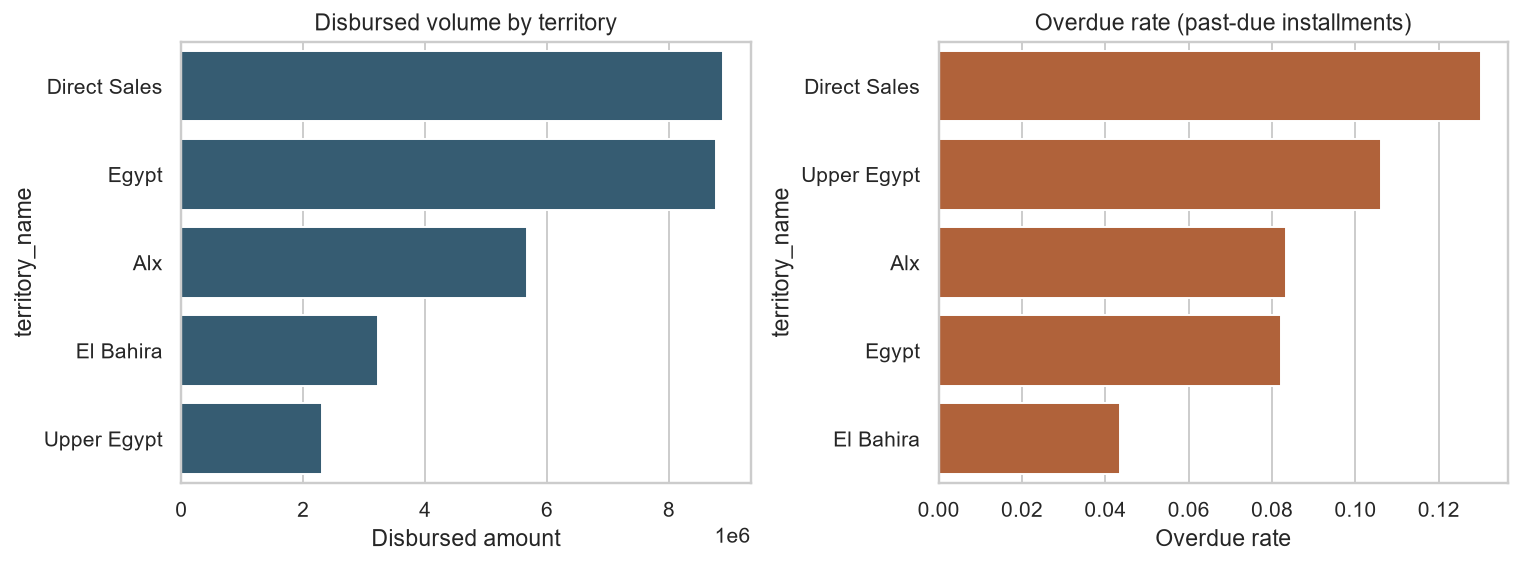

Assumption: 'over/under' means volume and collection quality. Largest books: Direct Sales and Egypt by disbursement. Collection stress is highest in Direct Sales (13.0% of past-due installments overdue) and lowest in El Bahira (4.3%). Upper Egypt is smaller in volume but has elevated delay risk — under-performing on quality, not size.


In [22]:
q2 = ra.q2_territories(enriched)
display(q2['table'].sort_values('disbursed', ascending=False))
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '03_territory_performance.png')))
print(q2['interpretation'])


### Q3. Top / bottom performers and target fairness

**Coverage note:** only employees present in employee_kpi (and matching commissions) are scored.


,employee_id,full_name,level_name,territory_name,target_amount,achieved_amount,attainment,approval_rate,collection_rate,comm_total,n_loans,avg_credit,delayed_rate
2,3,Amr Abd El-Monsef,Sales Director,Egypt,"3,128,572.70",2720498,0.87,100,52.80,"46,900.38",34,645.03,0.18
8,61,Karim Ashraf Shehata Tawfik,Team Leader,Direct Sales,"3,299,690.40",2869296,0.87,100,52.30,"47,641.42",36,637.97,0.06
1,2,Mostafa Fathy,Sales Director,Egypt,"4,429,767.80",3851972,0.87,100,49.90,"65,557.12",54,668.94,0.11
3,16,Hazem Semman Ali Eyasean Abd El Rahman,Area Manager,Alx,"2,977,114.25",2588795,0.87,100,49.70,"44,415.30",34,655.32,0.09
9,63,Eslam Wahid Mohamed El Sayed Ahmed Ghanayem,Team Leader,Direct Sales,"4,430,904.00",3852960,0.87,100,47.90,"68,633.32",43,658.35,0.05
5,22,Mirhan Yehia Mohamed El Sayed,Area Manager,Direct Sales,"4,168,823.60",3625064,0.87,100,47.50,"61,597.10",44,624.95,0.07
0,1,Ahmed Hassan,CEO,Egypt,"4,274,330.35",3716809,0.87,100,46.60,"63,034.52",46,639.54,0.09
7,56,Hamza Esmat Hamza Mohamed Hussein,Team Leader,El Bahira,"4,283,884.55",3725117,0.87,100,46.40,"64,415.62",46,662.98,0.11
6,43,Marco Morshed Habeel,Team Leader,Upper Egypt,"3,134,337.65",2725511,0.87,100,44.60,"46,237.20",33,641.03,0.18
4,17,Mohamed Farahat Wefky Hussein,Area Manager,Alx,"4,730,147.80",4113172,0.87,100,42.60,"69,158.88",50,664.30,0.12


Covered employee_ids: [1, 2, 3, 16, 17, 22, 43, 56, 61, 63]


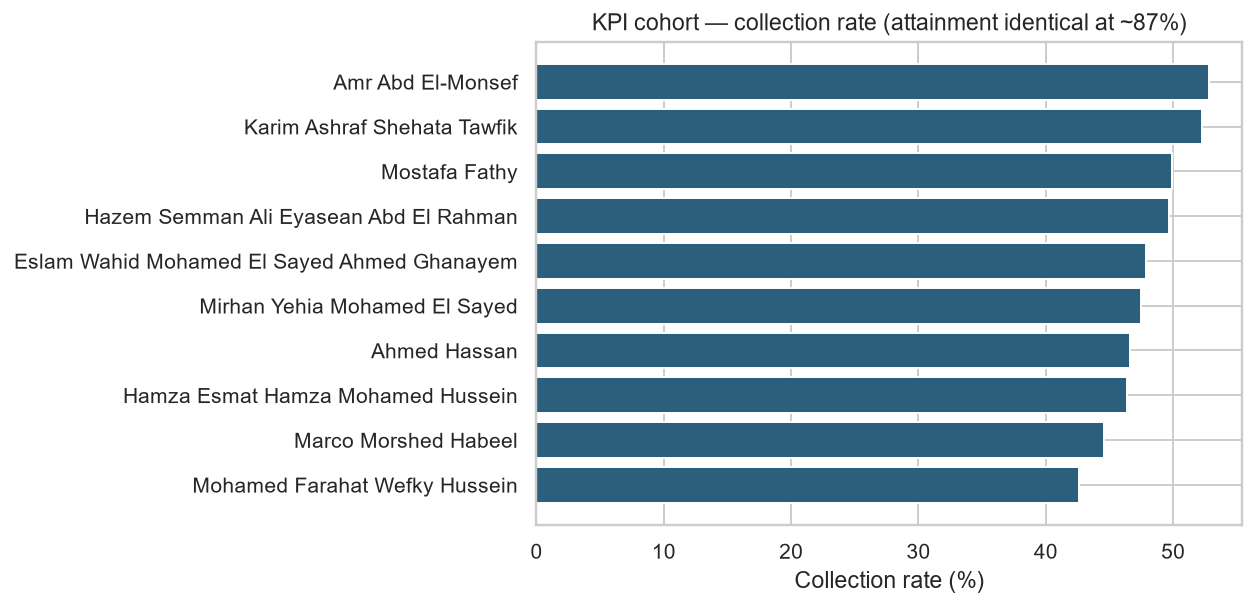

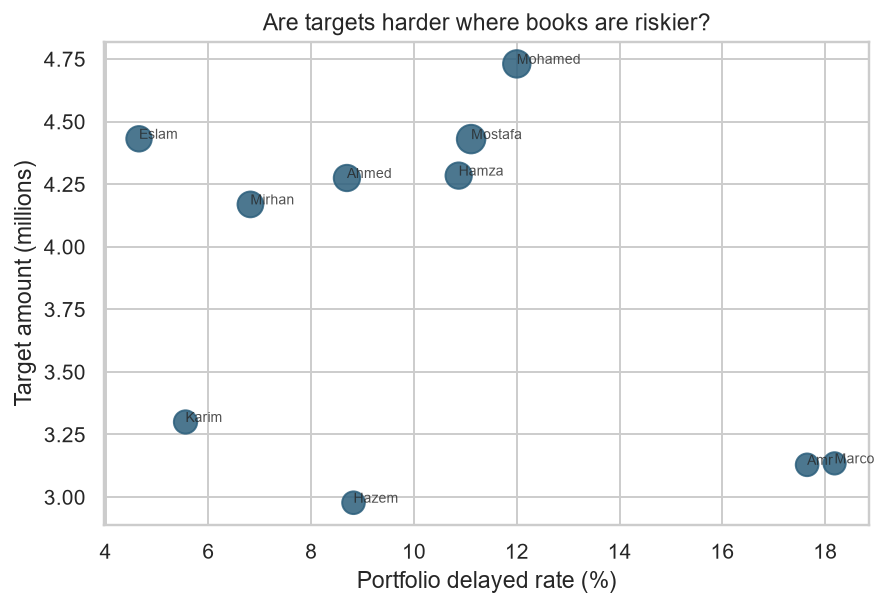

Coverage: KPI and commission data cover exactly these 10 employees: [1, 2, 3, 16, 17, 22, 43, 56, 61, 63]. All ten have identical attainment (~87.0% of target), so ranking by achieved/target is meaningless — targets appear scaled to achievement. Differentiator is collection_rate: best Amr Abd El-Monsef (52.8%), weakest Mohamed Farahat Wefky Hussein (42.6%). Targets do rise with book size, but not clearly with delayed_rate — fairness on difficulty is mixed.


In [23]:
q3 = ra.q3_performers(enriched, frames)
cols = ['employee_id','full_name','level_name','territory_name','target_amount','achieved_amount',
        'attainment','approval_rate','collection_rate','comm_total','n_loans','avg_credit','delayed_rate']
display(q3['table'][cols].sort_values('collection_rate', ascending=False))
print('Covered employee_ids:', q3['covered_employee_ids'])
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '04_kpi_performers.png')))
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '04b_target_fairness.png')))
print(q3['interpretation'])


### Q4. Overdue installment population

Overdue count: 79 status mix: {'Partial': 55, 'Pending': 24}

By territory:


territory_name
Direct Sales    32
Egypt           22
Alx             14
Upper Egypt      7
El Bahira        4
dtype: int64


By employee:


employee_name
Mirhan Yehia Mohamed El Sayed                  13
Eslam Wahid Mohamed El Sayed Ahmed Ghanayem    13
Mostafa Fathy                                   9
Amr Abd El-Monsef                               7
Marco Morshed Habeel                            7
Hazem Semman Ali Eyasean Abd El Rahman          7
Mohamed Farahat Wefky Hussein                   7
Ahmed Hassan                                    6
Karim Ashraf Shehata Tawfik                     6
Hamza Esmat Hamza Mohamed Hussein               4
dtype: int64


By loan size:


loan_size_band
<30k      11
30–60k    26
60–90k    18
90k+      24
dtype: int64


By credit band:


credit_band
≤500       12
501–600    11
601–700    19
701–800    24
801+       13
dtype: int64

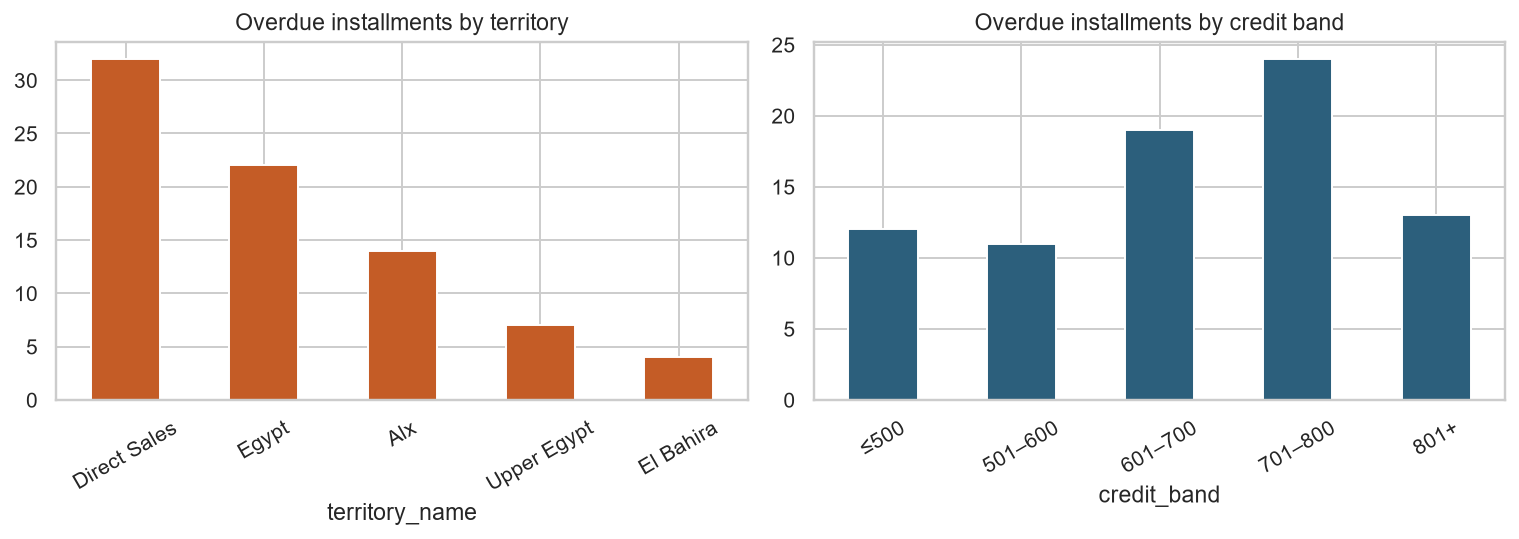

As of 2026-07-30, 79 installments are past due and not fully Paid ({'Partial': 55, 'Pending': 24}). Concentration: Direct Sales leads overdue count; top employee is Mirhan Yehia Mohamed El Sayed (13 overdue). Overdues appear across credit bands — higher scores are not clearly protected in this extract.


In [24]:
q4 = ra.q4_overdue_profile(enriched)
print('Overdue count:', q4['n_overdue'], 'status mix:', q4['status_mix'])
print('\nBy territory:'); display(q4['by_territory'])
print('\nBy employee:'); display(q4['by_employee'])
print('\nBy loan size:'); display(q4['by_loan_size'])
print('\nBy credit band:'); display(q4['by_credit'])
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '05_overdue_profile.png')))
print(q4['interpretation'])


### Q5. Early default-risk signals

Delay rate by number of risk flags (high PTI, rate>=16, short tenure):


,mean,count
risk_flags,,
0,0.06,72
1,0.08,210
2,0.17,107
3,0.16,31


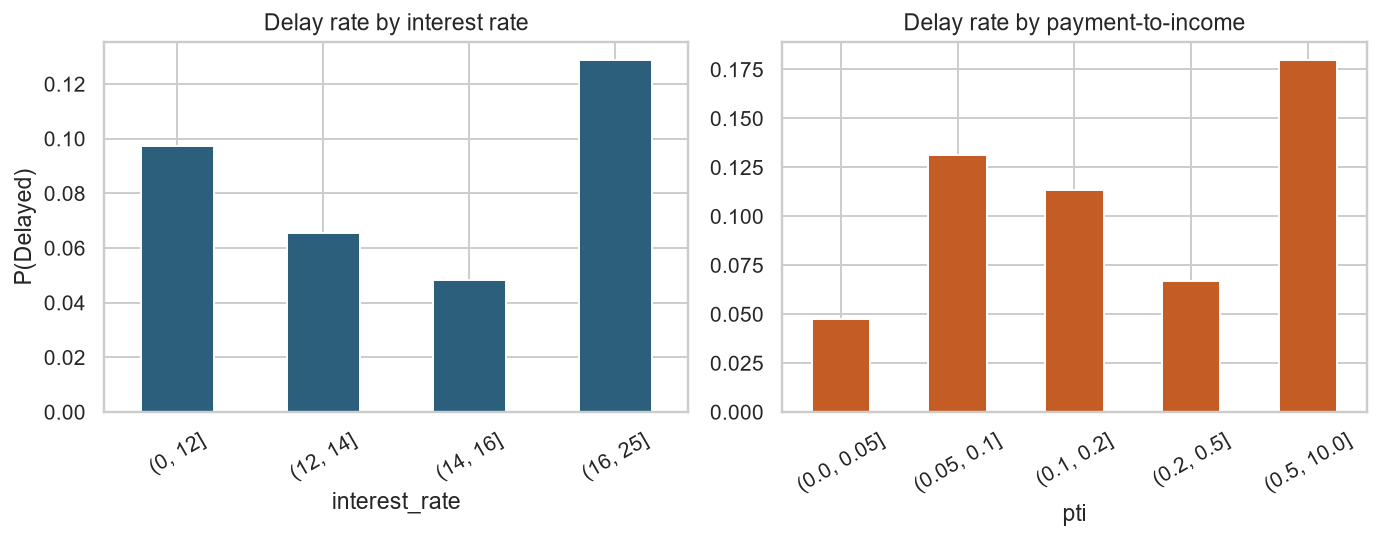

Before an account is marked Delayed, usable signals are: (1) payment-to-income (installment/salary) — PTI>0.5 shows ~18% delay vs ~9% otherwise; (2) interest rate ≥16% (pricing already embeds risk); (3) shorter tenures in this book co-occur with higher delay. Credit score alone is a weak separator here. Flag accounts with 2+ of these at origination for early outreach.


In [25]:
q5 = ra.q5_risk_signals(enriched)
print('Delay rate by number of risk flags (high PTI, rate>=16, short tenure):')
display(q5['by_flag_count'])
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '06_risk_signals.png')))
print(q5['interpretation'])


## Part 3 — One original insight

**Credit score is a weak predictor of Delayed loans in this book; affordability and pricing matter more.**


,mean,count
credit_band,,
≤500,0.12,49
501–600,0.10,112
601–700,0.11,100
701–800,0.10,109
801+,0.08,50


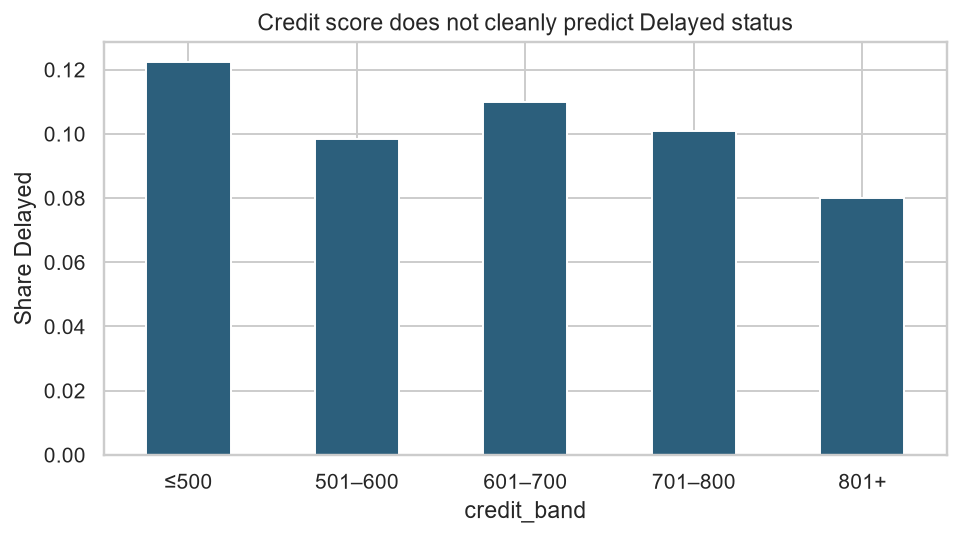

Unexpected finding: higher credit-score bands do not show lower Delayed rates in this dataset (801+ delayed share 8.0% vs 501–600 9.8%). Underwriting appears to lean on score, but realized risk tracks affordability (PTI) and rate more closely. Business implication: refresh scorecards with income-burden features, and do not treat a high score as a substitute for payment-capacity checks.


In [26]:
insight = ra.part3_insight(enriched)
display(insight['by_credit'])
display(Image(filename=str(ROOT / 'outputs' / 'charts' / '07_insight_credit.png')))
print(insight['interpretation'])


## Part 4 — Stakeholder package

Regenerate the 1-page summary and confirm chart outputs.


In [27]:
results = {
    'eda': eda, 'q1': q1, 'q2': q2, 'q3': q3, 'q4': q4, 'q5': q5, 'insight': insight
}
path = ra.write_executive_summary(results)
print('Wrote', path)
print('Charts:', sorted(p.name for p in (ROOT / 'outputs' / 'charts').glob('*.png')))
conn.close()


Wrote D:\Projects\Drive Finance Data Analysis\outputs\executive_summary.md
Charts: ['01_distributions.png', '02_portfolio_status.png', '03_territory_performance.png', '04_kpi_performers.png', '04b_target_fairness.png', '05_overdue_profile.png', '06_risk_signals.png', '07_insight_credit.png']


### Tools used

See NOTES.md in the project root.
